# Portfolio problem

In [134]:
import math
from pathlib import Path
import cvxpy as cp
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

from mis_dro.experiments import ExperimentName
from mis_dro.constants import IN_SAMPLE_TIME_WINDOW, OUT_OF_SAMPLE_TIME_WINDOW
from mis_dro.plot import *

from matplotlib import rc
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], "size":14})
rc('text', usetex=True)


In [135]:
mmc2_dir = Path("/", "Users", "patrick", "Datasets", "misdro", "mmc2")
# mmc2_dir = Path("/dcs/pg20/u1508153/datasets/misdro/mmc2")
assert mmc2_dir.exists()
dgp = "DowJones"
returns_df = pd.read_excel(mmc2_dir / "Datasets" / dgp / f"{dgp}.xlsx", sheet_name="Assets_Returns", header=None)
index_returns_df = pd.read_excel(mmc2_dir / "Datasets" / dgp / f"{dgp}.xlsx", sheet_name="Index_Returns", header=None)

In [136]:
# experiment_dir = Path("/dcs/large/u1508153/misdro/paper_bas/mmd_portfolio")
experiment_name = ExperimentName.kl_portfolio
experiment_dir = Path(f"/Users/patrick/experiments/misdro/paper_bas/{experiment_name.value}")
assert experiment_dir.exists()
all_results_df = pd.read_csv(experiment_dir / "results.csv", index_col=["uuid", "replication"])
all_results_df

mean_cost  var_cost  \
uuid                                 replication                        
0476020a-667a-475b-a036-b29598feac4d 0             0.024998  0.003980   
                                     1             0.013439  0.004527   
                                     2             0.008790  0.002081   
                                     3             0.028088  0.001964   
                                     4            -0.000823  0.004172   
...                                                     ...       ...   
7285942c-2e6c-4202-90cd-ef954c3c7643 104           0.001850  0.000181   
                                     105          -0.001846  0.000148   
                                     106          -0.006454  0.001083   
                                     107           0.007614  0.000345   
                                     108           0.001181  0.000585   

                                                                                           solution  \
uuid                                 replication                                                      
0476020a-667a-475b-a036-b29598feac4d 0            [4.920768005677304e-09, 1.2473459949010729e-08...   
                                     1            [3.864726353855574e-10, 1.07412133958714e-09, ...   
                                     2            [5.246939999016289e-10, 6.237876722974108e-09,...   
                                     3            [8.944718516637793e-10, 6.991143101482353e-10,...   
                                     4            [2.8936057316513235e-09, 2.860761718169876e-08...   
...                                                                                             ...   
7285942c-2e6c-4202-90cd-ef954c3c7643 104          [0.029068639119373865, 0.033090720270550704, 0...   
                                     105          [0.03321572386396494, 0.03784287429925622, 0.0...   
                                     106          [0.034883829806971065, 0.03802987248164945, 0....   
                                     107          [0.03835493921990218, 0.039472708957769706, 0....   
                                     108          [0.03383348485676907, 0.02641816095251582, 0.0...   

                                                  dgp_time  likelihood_time  \
uuid                                 replication                              
0476020a-667a-475b-a036-b29598feac4d 0            0.603697         0.000003   
                                     1            0.271133         0.000001   
                                     2            0.273292         0.000001   
                                     3            0.402401         0.000001   
                                     4            0.273060         0.000002   
...                                                    ...              ...   
7285942c-2e6c-4202-90cd-ef954c3c7643 104          0.236875         0.000001   
                                     105          0.237246         0.000001   
                                     106          0.280858         0.000001   
                                     107          0.237442         0.000002   
                                     108          0.236583         0.000001   

                                                  posterior_time  solve_time  \
uuid                                 replication                               
0476020a-667a-475b-a036-b29598feac4d 0                  0.000896    0.036744   
                                     1                  0.000517    0.012598   
                                     2                  0.000458    0.012788   
                                     3                  0.000416    0.011825   
                                     4                  0.000427    0.011952   
...                                                          ...         ...   
7285942c-2e6c-4202-90cd-ef954c3c7643 104                0.002103    0.116097   
            

In [137]:
# experiment_dir = Path("/dcs/large/u1508153/misdro/paper_bas/mmd_portfolio")
# assert experiment_dir.exists()
# kl_results_df = pd.read_csv(experiment_dir / "results.csv")
# NOTE filter out when log_partition_constant G is less than epsilon
# results_df = results_df.loc[results_df["log_partition_constant"] < results_df["epsilon"]]
# kl_results_df = kl_results_df.loc[kl_results_df["replication"] < 2].set_index(["uuid", "replication"])
# results_df = pd.concat([results_df, kl_results_df])
# results_df["algorithm"].unique().tolist()

In [138]:
# NOTE filter by DGP
filter_dgp = "DowJones"
results_df = all_results_df.loc[all_results_df["dgp"] == filter_dgp]
dataset = results_df["dataset"].unique()[0]

# NOTE filter out when log_partition_constant G is less than epsilon
# results_df = results_df.loc[results_df["log_partition_constant"] < results_df["epsilon"]]

if "out_of_sample_costs" in results_df.columns:
    results_df = results_df.rename(columns={"out_of_sample_costs": "out_of_sample_cost"})

def convert_str_to_float_list(str_list: str, list_len: int) -> list[float]:
    if str_list == "[]":
        return[np.nan for _ in range(list_len)]
    else:
        return [float(x) for x in str_list.strip('[]').split(',')]

# NOTE we always want the same number of test observations
assert np.isclose(results_df["num_test_observations"].var(), 0)
num_test_observations = results_df["num_test_observations"].unique()[0]
num_replications = results_df["num_replications"].unique()[0]
results_df["out_of_sample_cost"] = results_df["out_of_sample_cost"].map(lambda x: convert_str_to_float_list(x, num_test_observations))

# the log partition constant should always be the same for BAS
assert np.isclose(results_df.loc[results_df["algorithm"] == "kl_dro_bas"]["log_partition_constant"].var(), 0)
log_partition_constant = results_df.loc[results_df["algorithm"] == "kl_dro_bas"]["log_partition_constant"].unique()[0]

# special case for 1 test observation
if num_test_observations == 1:
    results_df["out_of_sample_cost"] = results_df["out_of_sample_cost"].map(lambda x: x[0])
elif num_test_observations > 1 and dataset == "portfolio":
    results_df["solution"] = results_df["solution"].map(lambda x: convert_str_to_float_list(x, num_test_observations))
else:
    raise NotImplementedError("Not supported yet!")


In [139]:
num_total_samples = []
for _, row in all_results_df.iterrows():
    if row["algorithm"] in ("kl_bdro", "kl_dro_bas"):
        num_total_samples.append(row["num_posterior_samples"])
    else:
        raise NotImplementedError()
results_df["num_total_samples"] = num_total_samples

results_df["sample_time"] = results_df["likelihood_time"] + results_df["posterior_time"]
gb = results_df.groupby(["algorithm", "num_total_samples"])
solve_time_df = gb.agg(
    mean_solve_time = pd.NamedAgg(column="solve_time", aggfunc=np.mean),
    std_solve_time = pd.NamedAgg(column="solve_time", aggfunc=np.std),
    mean_sample_time = pd.NamedAgg(column="sample_time", aggfunc=np.mean),
    std_sample_time = pd.NamedAgg(column="sample_time", aggfunc=np.std),
)
solve_time_df = solve_time_df.round(decimals=4)
solve_time_df["str_solve_time"] = solve_time_df[["mean_solve_time", "std_solve_time"]].apply(
    lambda x: f"{x['mean_solve_time']} ({x['std_solve_time']})", axis=1
)
solve_time_df["str_sample_time"] = solve_time_df[["mean_sample_time", "std_sample_time"]].apply(
    lambda x: f"{x['mean_sample_time']} ({x['std_sample_time']})", axis=1
)
print(solve_time_df[["str_solve_time", "str_sample_time"]].to_latex())


\begin{tabular}{llll}
\toprule
 &  & str_solve_time & str_sample_time \\
algorithm & num_total_samples &  &  \\
\midrule
\multirow[t]{3}{*}{kl_bdro} & 5 & 0.0326 (0.0062) & 0.0013 (0.001) \\
 & 10 & 0.0567 (0.0091) & 0.0016 (0.0008) \\
 & 30 & 0.1288 (0.0074) & 0.0025 (0.0009) \\
\cline{1-4}
kl_dro_bas & 1 & 0.0123 (0.0117) & 0.0004 (0.0004) \\
\cline{1-4}
\bottomrule
\end{tabular}



/var/folders/38/gm_d4yxj7bx11rp4p930zwnr0000gn/T/ipykernel_71955/279823982.py:11: FutureWarning: The provided callable <function mean at 0x10ada20c0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  solve_time_df = gb.agg(
/var/folders/38/gm_d4yxj7bx11rp4p930zwnr0000gn/T/ipykernel_71955/279823982.py:11: FutureWarning: The provided callable <function std at 0x10ada2200> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  solve_time_df = gb.agg(
/var/folders/38/gm_d4yxj7bx11rp4p930zwnr0000gn/T/ipykernel_71955/279823982.py:11: FutureWarning: The provided callable <function mean at 0x10ada20c0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "

In [140]:
# now only look at 30 posterior samples for BDRO
bdro_num_posterior_samples = 30
results_df = results_df.loc[(results_df["algorithm"] != "kl_bdro") | (results_df["num_posterior_samples"] == bdro_num_posterior_samples)]

In [141]:
gb = results_df.groupby(["algorithm", "epsilon"])
agg_list = []
for idx, group_df in gb:
    cost_list = []
    for i in range(num_replications):
        cost_list += group_df["out_of_sample_cost"].values[i]
    agg_list.append({
        "algorithm": idx[0],
        "epsilon": idx[1],
        "out_of_sample_mean": np.mean(cost_list),
        "out_of_sample_var": np.var(cost_list),
    })
agg_df = pd.DataFrame(agg_list).set_index(["algorithm", "epsilon"])
agg_df

out_of_sample_mean  out_of_sample_var
algorithm  epsilon                                       
kl_bdro    0.00001            0.006804           0.002552
           0.00002            0.006531           0.002450
           0.00005            0.006417           0.002262
           0.00010            0.006150           0.002115
           0.00020            0.005651           0.001928
           0.00050            0.005232           0.001579
           0.00100            0.004765           0.001321
           0.00200            0.004122           0.000986
           0.00500            0.003305           0.000688
           0.01000            0.002901           0.000580
           0.02000            0.002673           0.000530
           0.05000            0.002533           0.000502
           0.10000            0.002478           0.000494
           0.20000            0.002442           0.000490
           0.50000            0.002411           0.000489
           1.00000            0.002396           0.000488
kl_dro_bas 0.00001            0.006878           0.002601
           0.00002            0.006661           0.002516
           0.00005            0.006415           0.002336
           0.00010            0.006299           0.002215
           0.00020            0.005980           0.002051
           0.00050            0.005357           0.001771
           0.00100            0.005070           0.001484
           0.00200            0.004557           0.001207
           0.00500            0.003604           0.000808
           0.01000            0.003127           0.000640
           0.02000            0.002775           0.000559
           0.05000            0.002581           0.000515
           0.10000            0.002504           0.000502
           0.20000            0.002458           0.000495
           0.50000            0.002420           0.000492
           1.00000            0.002401           0.000491

In [142]:
def mean_variance_plot(
    axis: mpl.axis.Axis,
    df: pd.DataFrame,
    is_labelled: bool = True,
    pareto_front_col: str = "is_minimise_pareto_front",
    offset: float = 1.0,
    special_epsilons: list[float] = [0.1, 0.5],
    log_partition_constant: float = 0.0,
    **kwargs,
) -> None:
    # plot mean-variance trade-off
    epsilon_list = list(df.index.get_level_values("epsilon"))
    fillstyles = ["full" if is_pareto else "none" for is_pareto in df[pareto_front_col].tolist() ] 
    out_of_sample_var = df["out_of_sample_var"].to_list()
    out_of_sample_mean = df["out_of_sample_mean"].to_list()
    label=kwargs.pop("label")
    for i in range(len(out_of_sample_var)):
        if i == 0 and is_labelled:
            local_label = label
        else:
            local_label='_nolegend_'
        axis.plot(out_of_sample_var[i], out_of_sample_mean[i], markersize=4, fillstyle=fillstyles[i], **kwargs, label=local_label)

    axis.plot(df["out_of_sample_var"], df["out_of_sample_mean"], linestyle=kwargs["linestyle"], markersize=0, color=kwargs["color"], label='_nolegend_', alpha=kwargs["alpha"])
    # axis.scatter(posterior_var, df["mean_cost"]["mean"], s=100*np.sqrt(np.array(epsilon_list)), **kwargs)
    if is_labelled:
        
        for i, epsilon in enumerate(epsilon_list):
            # if i % 4 == 0:

            if epsilon in special_epsilons:
                if kwargs["color"] == AlgorithmColor.kl_dro_bas:
                    ha = "right"
                    va = "bottom"
                    local_offset = offset
                # else if line is black then put text on top right
                elif kwargs["color"] == AlgorithmColor.kl_bdro:
                    ha = "left"
                    va = "top"
                    # offset = 1 if i==0 or i == len(epsilon_list) else 5
                    local_offset = -offset
                axis.text(
                    # df["out_of_sample_var"][:, :, epsilon, :].iloc[0] + local_offset,
                    # df["out_of_sample_mean"][:, :, epsilon, :].iloc[0],
                    df["out_of_sample_var"].iloc[i] - local_offset,
                    df["out_of_sample_mean"].iloc[i] + local_offset,
                    np.round(epsilon + log_partition_constant, 5),
                    ha=ha,
                    va=va,
                    color=kwargs["color"],
                )

/var/folders/38/gm_d4yxj7bx11rp4p930zwnr0000gn/T/ipykernel_71955/3063998650.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


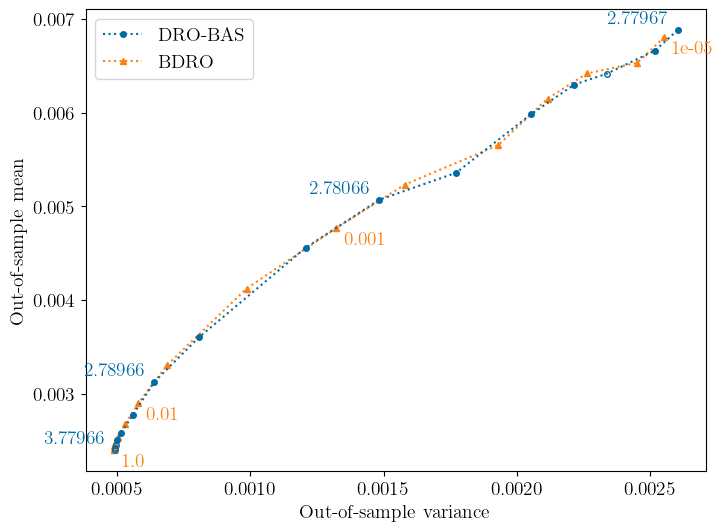

In [192]:
fig, ax = plt.subplots(figsize=(8,6))
df = agg_df
df.loc[:, "is_maximise_pareto_front"] = is_maximise_pareto_front(df["out_of_sample_var"].values, df["out_of_sample_mean"].values)
for algorithm, group_df in df.groupby("algorithm"):
    if algorithm == "kl_dro_bas":
        local_log_partition_constant = log_partition_constant
    else:
        local_log_partition_constant = 0
    mean_variance_plot(ax, group_df, is_labelled=True, offset=0.00003, alpha=1.0, **algorithm_style(algorithm), pareto_front_col="is_maximise_pareto_front", special_epsilons=[0.00001, 0.001, 0.01, 1.0], log_partition_constant=local_log_partition_constant)
handles, labels = ax.get_legend_handles_labels()
order = [1,0]
ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order])
# ax.legend()
ax.set_xlabel("Out-of-sample variance")
ax.set_ylabel("Out-of-sample mean")
# ax.set_xlim(agg_df["out_of_sample_var"].min(), agg_df["out_of_sample_var"].max())
# ax.set_ylim(agg_df["out_of_sample_mean"].min(), agg_df["out_of_sample_mean"].min())
fig.savefig(f"/Users/patrick/Experiments/misdro/paper_bas_figures/{experiment_name}_mean_var_{filter_dgp}.pdf", bbox_inches="tight")

fig.show()

/var/folders/38/gm_d4yxj7bx11rp4p930zwnr0000gn/T/ipykernel_71955/4121602414.py:56: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


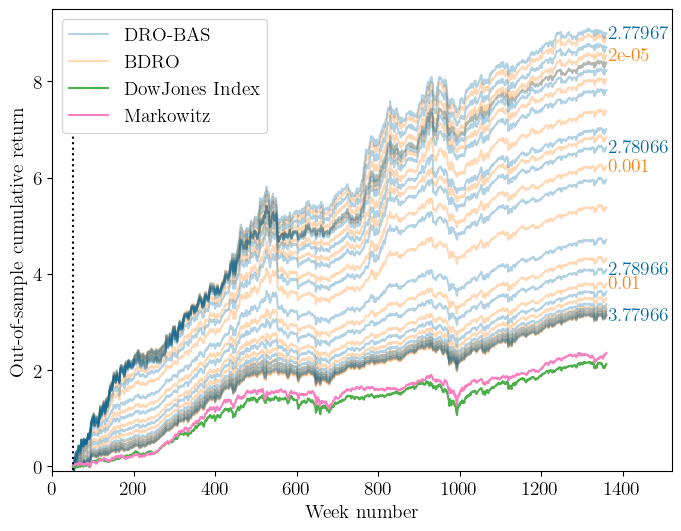

In [193]:
fig, ax = plt.subplots(figsize=(8,6))
num_time_windows = math.floor((len(returns_df) - IN_SAMPLE_TIME_WINDOW) / OUT_OF_SAMPLE_TIME_WINDOW)
num_stocks = int(len(returns_df.columns))
last_week = len(index_returns_df.iloc[IN_SAMPLE_TIME_WINDOW:])
bdro_labelled = False
dro_bas_labelled = False
oos_week_numbers = [IN_SAMPLE_TIME_WINDOW + i for i in range(OUT_OF_SAMPLE_TIME_WINDOW * num_time_windows)]
for (algorithm, epsilon), group_df in gb:
    # dro_returns = group_df[week_cols].values.flatten()
    assert OUT_OF_SAMPLE_TIME_WINDOW * num_time_windows == len(group_df) * len(group_df["out_of_sample_cost"].values[0])
    cost_list = []
    for i in range(num_replications):
        cost_list += group_df["out_of_sample_cost"].values[i]
    dro_returns = np.array(cost_list)
    if not dro_bas_labelled and algorithm == "kl_dro_bas":
        label = AlgorithmName[algorithm].value
        dro_bas_labelled = True
    elif not bdro_labelled and algorithm == "kl_bdro":
        label = AlgorithmName[algorithm].value
        bdro_labelled = True
    else:
        label='_nolegend_'
    ax.plot(oos_week_numbers, np.cumsum(dro_returns), label=label, alpha=0.3, color=AlgorithmColor[algorithm].value)
    if algorithm == "kl_dro_bas" and epsilon in [0.00001, 0.001, 0.01, 1.0]:
        ax.text(last_week + IN_SAMPLE_TIME_WINDOW, np.cumsum(dro_returns)[last_week-4]-0.1, np.round(log_partition_constant + epsilon, 5), color=AlgorithmColor[algorithm].value)
    elif algorithm == "kl_bdro" and  epsilon in [0.00002, 0.001, 0.01]:
        ax.text(last_week + IN_SAMPLE_TIME_WINDOW, np.cumsum(dro_returns)[last_week-4]-0.1, epsilon, color=AlgorithmColor[algorithm].value)

CB_color_cycle = ['#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']
ax.plot(oos_week_numbers, np.cumsum(index_returns_df.iloc[IN_SAMPLE_TIME_WINDOW:IN_SAMPLE_TIME_WINDOW+OUT_OF_SAMPLE_TIME_WINDOW * num_time_windows].values), label=f"{dgp} Index", color=CB_color_cycle[0])
# for baseline_model in ["CZeSD", "KP_SSD", "L_SSD", "LR_ASSD", "MeanVar", "RMZ_SSD"]:

for i, baseline_model in enumerate(["MeanVar"]):
    baseline_model_label = baseline_model if baseline_model != "MeanVar" else "Markowitz"
    baseline_portfolio_txt = mmc2_dir / "Solutions" / dgp / f"OptPortfolios_{baseline_model}_{dgp}.txt"
    baseline_portfolio = np.loadtxt(baseline_portfolio_txt).T[:num_time_windows, :]
    baseline_returns_txt = mmc2_dir / "Solutions" / dgp / f"OutofSamplePortReturns_{baseline_model}_{dgp}_List.txt" 
    baseline_returns = np.loadtxt(baseline_returns_txt)
    ax.plot(oos_week_numbers, np.cumsum(baseline_returns[:OUT_OF_SAMPLE_TIME_WINDOW * num_time_windows]), label=baseline_model_label, color=CB_color_cycle[i+1])

ax.set_xlabel("Week number")
ax.set_ylabel("Out-of-sample cumulative return")
# ax.set_xlim(2000)
ax.set_xlim(0, 1520)
ax.set_ylim(-0.1, 9.5)
ax.vlines(52, -0.3, 6.9, color="black", linestyle=":")
# ax.set_title(dgp + r" cumulative return vs Benchmarks")
handles, labels = ax.get_legend_handles_labels()
order = [1,0,2,3]
ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order])
# ax.legend()
plt.savefig(f"/Users/patrick/Experiments/misdro/paper_bas_figures/{experiment_name}_cum_returns_{filter_dgp}.pdf", bbox_inches="tight")

fig.show()